## Digit Recognizer
https://www.kaggle.com/c/digit-recognizer

In [ ]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Загружаем исходные данные

In [ ]:
path_data_zip = '/content/drive/MyDrive/DFD_Учёба/Домашнее Задание/14. Компьютерное зрение/ДЗ_1_Сегментация и детекция объектов/Data.zip'

In [ ]:
with zipfile.ZipFile(file=path_data_zip) as data:
  data_list = [file.filename for file in data.filelist]
  print(f' Содержимое zip архива: {data_list}')
  data.extractall()

 Содержимое zip архива: ['sample_submission.csv', 'test.csv', 'train.csv']


In [ ]:
sample_submission = pd.read_csv(data_list[0], delimiter=',')
test = pd.read_csv(data_list[1], delimiter=',')   # test.values
train = pd.read_csv(data_list[2], delimiter=',')  # train.values

In [ ]:
test.head(3)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train.head(3)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Формируем массив только с пиксилями, без target_class
test_values = test.values
train_values = train.values          # Обучающий массив, который содержит target_class
train_values = train_values[:, 1:]   # Обучающий массив, без target_class

print(f' test: {test_values.shape}, train: {train_values.shape}')

 test: (28000, 784), train: (42000, 784)


In [ ]:
# 2 Метод получения массивов
# train_np = np.loadtxt(data_list[2], delimiter=',', skiprows=1)
# test_np = np.loadtxt(data_list[1], delimiter=',', skiprows=1)

In [ ]:
# сохраняем разметку в отдельную переменную
train_target_class = train['label'].values
# приводим размерность к удобному для обработки виду
train_img = np.resize(train_values, (train_values.shape[0], 28, 28))
test_img = np.resize(test_values, (test_values.shape[0], 28, 28))

In [ ]:
train_target_class

array([1, 0, 1, ..., 7, 6, 9])

## Визуализируем исходные данные

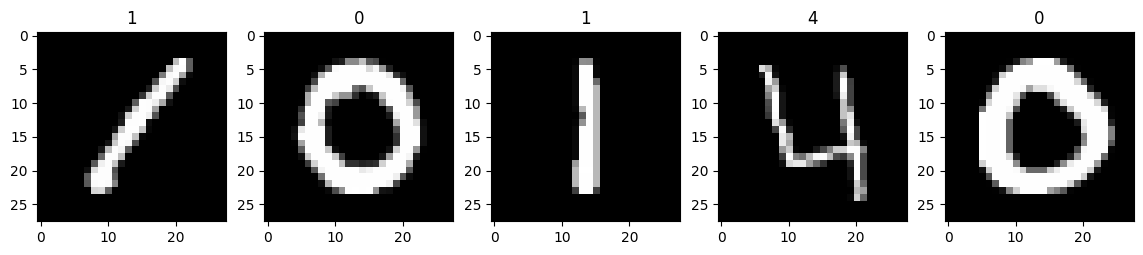

In [ ]:
fig = plt.figure(figsize=(20, 10))
for i, img in enumerate(train_img[0:5], 1):
    subplot = fig.add_subplot(1, 7, i)
    plt.imshow(img, cmap='gray');
    subplot.set_title('%s' % train_target_class[i - 1]);

## Гистограммы градиентов (HOG)

In [ ]:
from skimage.feature import hog

In [ ]:
def HOG(array_images):
  hog_descriptors_vector = []
  hog_images = []

  for image in array_images:
    feature_descriptor, hog_image = hog(image=image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm = 'L2-Hys', visualize=True)

    hog_descriptors_vector.append(feature_descriptor)
    hog_images.append(hog_image)

  hog_descriptors_vector = np.array(hog_descriptors_vector)
  hog_images = np.array(hog_images)
  return (hog_descriptors_vector, hog_images)

In [ ]:
# Преобразование данных
train_hog = HOG(train_img)

In [ ]:
# cсформированы вектора, каждое изображение содержит вектор с 144 признаками
train_hog[0].shape

(42000, 144)

In [ ]:
train_hog[1].shape # можно везуализировать изображение в результате преобразования гистограмм градиентов

(42000, 28, 28)

In [ ]:
test_hog = HOG(test_img)

In [ ]:
test_hog[0].shape

(28000, 144)

### Дополнительно. Метод главных компонент (PCI). Уменьшение размерности признаков

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
def PCI(array_hog_train, array_hog_test, n_components=50):
  pca = PCA(n_components=n_components)
  train_pca = pca.fit_transform(array_hog_train)
  test_pca = pca.transform(array_hog_test)
  return (train_pca, test_pca)

In [ ]:
# Для каждого изображения количество признаков уменьшено до 70
train_pca, test_pci = PCI(train_hog[0], test_hog[0], n_components=70)

In [ ]:
print(train_pca.shape, test_pci.shape)

(42000, 70) (28000, 70)


## МОДЕЛИ

In [ ]:
from sklearn import metrics
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [ ]:
train['label'].value_counts(normalize=True)*100 # Видим, что классы сбалансированы!

,proportion
label,
1,11.152381
7,10.478571
3,10.359524
9,9.971429
2,9.945238
6,9.850000
0,9.838095
4,9.695238
8,9.673810


## LogisticRegression

In [ ]:
# МОДЕЛЬ ЛОГИЧЕСКОЙ РЕГРЕССИИ
model_LogReg = LogisticRegression(random_state=1982)

In [ ]:
model_LogReg.fit(train_pca, train_target_class)

LogisticRegression(random_state=1982)

In [ ]:
# ПРОГНОЗНЫЕ ЗНАЧЕНИЯ ТЕСТОВОЙ ВЫБОРКИ
predict_LogReg = model_LogReg.predict(test_pci)
predict_LogReg.shape

(28000,)

In [ ]:
# accuracy_score тренировочной выборки
metrics.accuracy_score(train_target_class, predict_train_class)

0.9433809523809524

**Крос-Валидация модели ЛОГИЧЕСКОЙ РЕГРЕССИИ**

In [ ]:
accuracy_logReg = cross_val_score(estimator=model_LogReg, X=train_pca, y=train_target_class, cv=5, scoring='accuracy')

In [ ]:
recall_logReg = cross_val_score(estimator=model_LogReg, X=train_pca, y=train_target_class, cv=5, scoring='recall_macro')

In [ ]:
precision_logReg = cross_val_score(estimator=model_LogReg, X=train_pca, y=train_target_class, cv=6, scoring='precision_macro')

In [ ]:
df_res_LogReg = pd.DataFrame({'accuracy_mean': np.mean(accuracy_logReg), 'recall_mean': np.mean(recall_logReg), 'precision_mean': np.mean(precision_logReg)},  index=['model_LogReg'])

In [ ]:
df_res_LogReg

,accuracy_mean,recall_mean,precision_mean
model_LogReg,0.939667,0.939508,0.938387


## Модель LinearSVC. Линейный метод опорных векторов

In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
model_LinearSVC = LinearSVC(random_state=1982)

In [ ]:
model_LinearSVC.fit(train_pca, train_target_class)

LinearSVC(random_state=1982)

In [ ]:
# ПРОГНОЗНЫЕ ЗНАЧЕНИЯ ТЕСТОВОЙ ВЫБОРКИ
predict_LinearSVC = model_LinearSVC.predict(test_pci)
predict_LinearSVC.shape

(28000,)

**Крос-Валидация модели LinearSVC**

In [ ]:
accuracy_LinearSVC = cross_val_score(estimator=model_LinearSVC, X=train_pca, y=train_target_class, cv=5, scoring='accuracy')

In [ ]:
recall_LinearSVC = cross_val_score(estimator=model_LinearSVC, X=train_pca, y=train_target_class, cv=5, scoring='recall_macro')

In [ ]:
precision_LinearSVC = cross_val_score(estimator=model_LinearSVC, X=train_pca, y=train_target_class, cv=6, scoring='precision_macro')

In [ ]:
df_res_LinearSVC = pd.DataFrame({'accuracy_mean': np.mean(accuracy_LinearSVC), 'recall_mean': np.mean(recall_LinearSVC), 'precision_mean': np.mean(precision_LinearSVC)},  index=['model_LinearSVC'])

In [ ]:
df_res_LinearSVC

,accuracy_mean,recall_mean,precision_mean
model_LinearSVC,0.932405,0.932177,0.931885


In [ ]:
pd.concat([df_res_LogReg, df_res_LinearSVC])

,accuracy_mean,recall_mean,precision_mean
model_LogReg,0.939667,0.939508,0.938387
model_LinearSVC,0.932405,0.932177,0.931885


## Формирования DataFreme и  файла csv с результатами работы модели на ТЕСТОВОЙ ВЫБОРКЕ

In [ ]:
df_result_test = pd.DataFrame({'ImageId': np.arange(1, 28001), 'Label': predict_LogReg})

In [227]:
df_result_test

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [228]:
df_result_test.to_csv('result.csv', index=False)

In [229]:
# Проверка, загрузка экспортированного файла
pd.read_csv('result.csv').head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


# Public Score: **0,93946**

In [ ]:
# Public Score: 0,93946